## Before you start

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`.

In [ ]:
!nvidia-smi

Wed Sep 25 07:09:08 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla T4                       Off | 00000000:00:04.0 Off |                    0 |
| N/A   40C    P8               9W /  70W |      0MiB / 15360MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [ ]:
import os
HOME = os.getcwd()
print(HOME)

/content


In [ ]:
# Pip install method (recommended)

!pip install ultralytics

from IPython import display
display.clear_output()

import ultralytics
ultralytics.checks()

Ultralytics YOLOv8.2.100 🚀 Python-3.10.12 torch-2.4.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 33.2/112.6 GB disk)


In [ ]:
# Git clone method (for development)

# %cd {HOME}
# !git clone github.com/ultralytics/ultralytics
# %cd {HOME}/ultralytics
# !pip install -e .

# from IPython import display
# display.clear_output()

# import ultralytics
# ultralytics.checks()

In [ ]:
from ultralytics import YOLO

from IPython.display import display, Image

In [ ]:
!mkdir {HOME}/datasets
%cd {HOME}/datasets

!pip install roboflow --quiet

from roboflow import Roboflow
rf = Roboflow(api_key="YOUR_API_KEY")
project = rf.workspace("YOUR_WORKSPACE").project("YOUR_PROJECT")
version = project.version(1)
dataset = version.download("folder")


/content/datasets
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.9 MB/s eta 0:00:00
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to BrainTumour-1 in folder:: 100%|██████████| 5028/5028 [00:01<00:00, 4328.15it/s]


## Custom Training

In [ ]:
%cd {HOME}

!yolo task=classify mode=train model=yolov8m-cls.pt data={dataset.location} epochs=50 imgsz=640 cache=True verbose=True save_txt=True

/content
Ultralytics YOLOv8.2.100 🚀 Python-3.10.12 torch-2.4.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
engine/trainer: task=classify, mode=train, model=yolov8m-cls.pt, data=/content/datasets/BrainTumour-1, epochs=50, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=True, device=None, workers=8, project=None, name=train2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=True, save_conf=False, save_crop=False, show_labels=True, s

In [ ]:
!ls -la {HOME}/runs/classify/train2/

total 5316
drwxr-xr-x 4 root root   4096 Sep 24 15:44 .
drwxr-xr-x 4 root root   4096 Sep 24 13:30 ..
-rw-r--r-- 1 root root   1552 Sep 24 13:30 args.yaml
-rw-r--r-- 1 root root 131512 Sep 24 15:44 confusion_matrix_normalized.png
-rw-r--r-- 1 root root 124626 Sep 24 15:44 confusion_matrix.png
-rw-r--r-- 1 root root 193655 Sep 24 15:44 events.out.tfevents.1727184608.0c79ba86ca42.1626.0
drwxr-xr-x 2 root root   4096 Sep 24 13:30 labels
-rw-r--r-- 1 root root   9792 Sep 24 15:43 results.csv
-rw-r--r-- 1 root root 107771 Sep 24 15:44 results.png
-rw-r--r-- 1 root root 379317 Sep 24 13:30 train_batch0.jpg
-rw-r--r-- 1 root root 375983 Sep 24 13:30 train_batch1.jpg
-rw-r--r-- 1 root root 365523 Sep 24 13:30 train_batch2.jpg
-rw-r--r-- 1 root root 374496 Sep 24 15:17 train_batch8800.jpg
-rw-r--r-- 1 root root 398877 Sep 24 15:17 train_batch8801.jpg
-rw-r--r-- 1 root root 404774 Sep 24 15:17 train_batch8802.jpg
-rw-r--r-- 1 root root 421571 Sep 24 15:43 val_batch0_labels.jpg
-rw-r--r-- 1 root 

In [ ]:
!cat {HOME}/runs/classify/train2/results.csv | head -10

                  epoch,             train/loss,  metrics/accuracy_top1,  metrics/accuracy_top5,               val/loss,                 lr/pg0,                 lr/pg1,                 lr/pg2
                      0,                0.26657,                 0.7242,                      1,                0.69499,                    0.1,                    0.1,                    0.1
                      1,                0.17981,                0.83452,                      1,                0.41385,                    0.1,                    0.1,                    0.1
                      2,                0.15695,                0.86477,                      1,                0.39399,                0.09802,                0.09802,                0.09802
                      3,                0.14038,                0.89146,                      1,                0.32446,                0.09604,                0.09604,                0.09604
                      4,                

## Validate Custom Model

In [ ]:
%cd {HOME}

!yolo task=classify mode=val model={HOME}/runs/classify/train/weights/best.pt data={dataset.location}

/content
Ultralytics YOLOv8.2.100 🚀 Python-3.10.12 torch-2.4.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
YOLOv8m-cls summary (fused): 103 layers, 15,767,780 parameters, 0 gradients, 41.6 GFLOPs
train: /content/datasets/BrainTumour-1/train... found 3508 images in 4 classes ✅ 
val: /content/datasets/BrainTumour-1/val... found 1002 images in 4 classes ✅ 
test: /content/datasets/BrainTumour-1/test... found 501 images in 4 classes ✅ 
val: Scanning /content/datasets/BrainTumour-1/val... 1002 images, 0 corrupt: 100% 1002/1002 [00:00<?, ?it/s]
               classes   top1_acc   top5_acc: 100% 63/63 [00:17<00:00,  3.55it/s]
                   all       0.99          1
Speed: 0.9ms preprocess, 11.9ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to runs/classify/val
💡 Learn more at https://docs.ultralytics.com/modes/val


## Inference with Custom Model

In [ ]:
%cd {HOME}
!yolo task=classify mode=predict model={HOME}/runs/classify/train/weights/best.pt conf=0.6 source={dataset.location}/test/glioma_tumor

/content
Ultralytics YOLOv8.2.100 🚀 Python-3.10.12 torch-2.4.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
YOLOv8m-cls summary (fused): 103 layers, 15,767,780 parameters, 0 gradients, 41.6 GFLOPs

image 1/153 /content/datasets/BrainTumour-1/test/glioma_tumor/gg-103-_jpg.rf.1d793cd4865cd84800408386e71b14c4.jpg: 640x640 glioma_tumor 1.00, meningioma_tumor 0.00, no_tumor 0.00, pituitary_tumor 0.00, 20.9ms
image 2/153 /content/datasets/BrainTumour-1/test/glioma_tumor/gg-106-_jpg.rf.6fb4f7c3347f808e2e7a3934b8f7823d.jpg: 640x640 glioma_tumor 1.00, meningioma_tumor 0.00, pituitary_tumor 0.00, no_tumor 0.00, 20.9ms
image 3/153 /content/datasets/BrainTumour-1/test/glioma_tumor/gg-109-_jpg.rf.b625ea0f46320952b5bd3c277c06be02.jpg: 640x640 glioma_tumor 1.00, meningioma_tumor 0.00, pituitary_tumor 0.00, no_tumor 0.00, 20.8ms
image 4/153 /content/datasets/BrainTumour-1/test/glioma_tumor/gg-112-_jpg.rf.fe0730ec71eafe4fb233bde5a0e53145.jpg: 640x640 glioma_tumor 1.00, pituitary_tumor 0.00, meningioma_tumor 0.00,

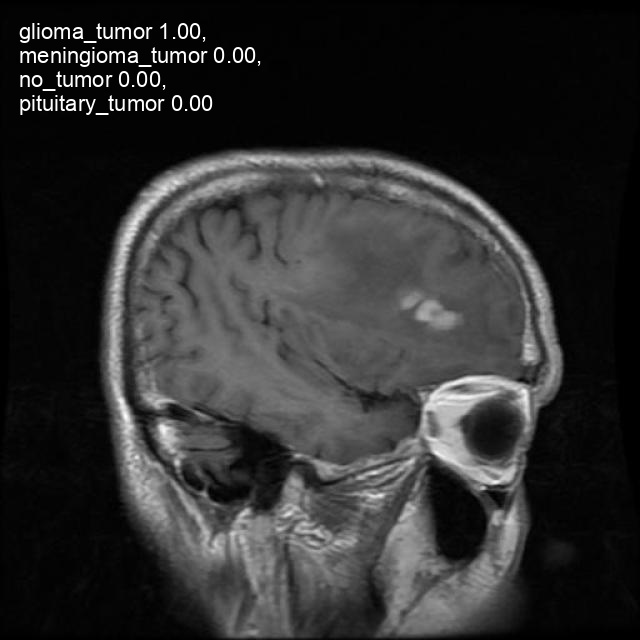

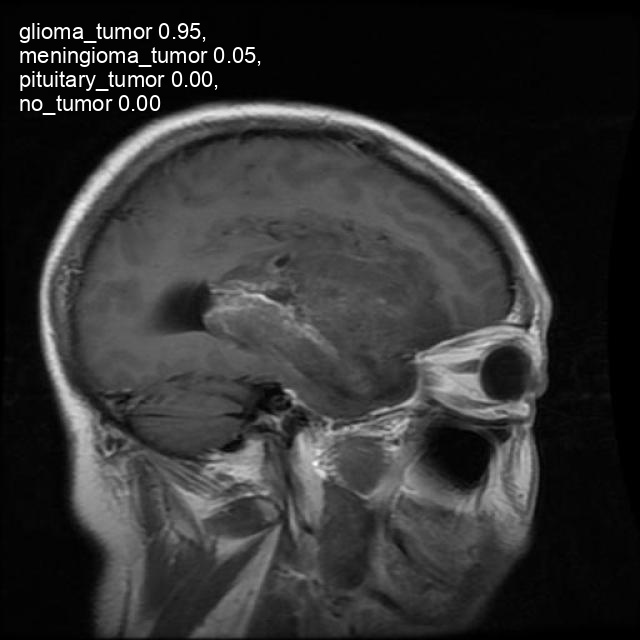

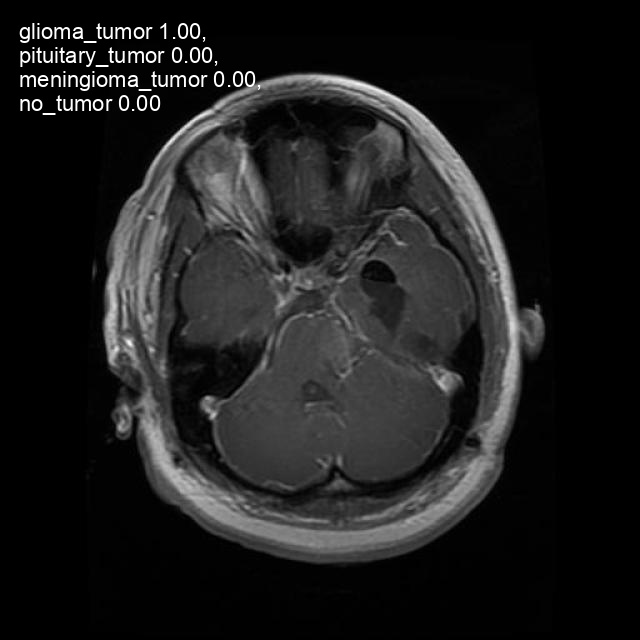

In [ ]:
import glob
from IPython.display import Image, display

for image_path in glob.glob(f'{HOME}/runs/classify/predict/*.jpg')[:3]:
      display(Image(filename=image_path, width=600))
      print("\n")